In [11]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_results(filepath):
    """Parse results.log into a dict keyed by (topology, size).
    Takes the max across processes for each timing phase.
    Only keeps the first occurrence of each (topology, size) config."""
    results = {}
    current_config = None
    proc_data = {}

    def save_config():
        nonlocal current_config, proc_data
        if current_config and current_config not in results and proc_data:
            phases = ['Computation', 'Exchange', 'Global comm', 'Idle']
            agg = {}
            for phase in phases:
                agg[phase] = max(proc_data[r].get(phase, 0) for r in proc_data)
            results[current_config] = agg

    with open(filepath) as f:
        for line in f:
            m = re.match(r'===Config:\s*(\d+)\s+(\d+),\s*Size:\s*(\d+)x(\d+)', line)
            if m:
                save_config()
                px, py, sx, sy = m.groups()
                current_config = (f'{px}x{py}', int(sx))
                proc_data = {}
                continue

            m = re.match(r'\s*\((\d+)\)\s+(Computation|Exchange|Global comm|Idle):\s+([\d.]+)', line)
            if m:
                rank, phase, val = int(m.group(1)), m.group(2), float(m.group(3))
                if rank not in proc_data:
                    proc_data[rank] = {}
                proc_data[rank][phase] = val

    save_config()
    return results

data = parse_results('results.log')
for k, v in sorted(data.items(), key=lambda x: (x[0][0], x[0][1])):
    print(f'{k}: {v}')

('1x4', 100): {'Computation': 0.016517, 'Exchange': 0.0014, 'Global comm': 0.001728, 'Idle': 0.000129}
('1x4', 200): {'Computation': 0.134531, 'Exchange': 0.004359, 'Global comm': 0.005676, 'Idle': 0.000559}
('1x4', 400): {'Computation': 1.22935, 'Exchange': 0.010561, 'Global comm': 0.025429, 'Idle': 0.002113}
('1x4', 800): {'Computation': 9.938181, 'Exchange': 0.024227, 'Global comm': 0.224818, 'Idle': 0.008688}
('2x2', 100): {'Computation': 0.016074, 'Exchange': 0.001775, 'Global comm': 0.001552, 'Idle': 0.000139}
('2x2', 200): {'Computation': 0.131134, 'Exchange': 0.004762, 'Global comm': 0.004265, 'Idle': 0.000563}
('2x2', 400): {'Computation': 1.208334, 'Exchange': 0.011503, 'Global comm': 0.023315, 'Idle': 0.002122}
('2x2', 800): {'Computation': 9.823195, 'Exchange': 0.03815, 'Global comm': 0.218318, 'Idle': 0.008345}


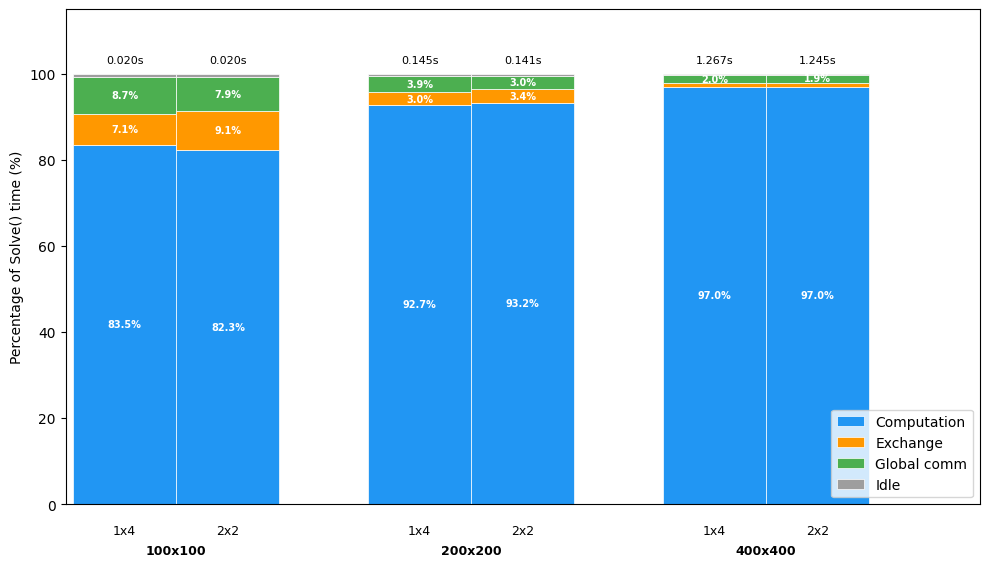

In [17]:
sizes = [100, 200, 400, 800][:-1]
topologies = ['1x4', '2x2']
phases = ['Computation', 'Exchange', 'Global comm', 'Idle']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9E9E9E']

fig, ax = plt.subplots(figsize=(10, 6))

n_sizes = len(sizes)
bar_width = 0.35
group_gap = 0.3
group_width = 2 * bar_width + group_gap
group_centers = np.arange(n_sizes) * group_width

for j, topo in enumerate(topologies):
    bottoms = np.zeros(n_sizes)
    x_pos = group_centers + j * bar_width
    totals = np.array([sum(data[(topo, s)][p] for p in phases) for s in sizes])
    for i, phase in enumerate(phases):
        vals = np.array([data[(topo, s)][phase] for s in sizes])
        pcts = vals / totals * 100
        bars = ax.bar(x_pos, pcts, bar_width, bottom=bottoms,
               label=phase if j == 0 else '',
               color=colors[i], edgecolor='white', linewidth=0.5)

        # Percentage labels inside bars
        for k, (bar, pct) in enumerate(zip(bars, pcts)):
            if pct >= 1:
                ax.text(bar.get_x() + bar.get_width() / 2, bottoms[k] + pct / 2,
                        f'{pct:.1f}%', ha='center', va='center', fontsize=7,
                        color='white', fontweight='bold')

        bottoms += pcts

    # Solve time labels
    for k, s in enumerate(sizes):
        ax.text(x_pos[k], 102, f'{totals[k]:.3f}s', ha='center', va='bottom', fontsize=8)

# Topology labels under each bar
ax.set_xticks([])
for j, topo in enumerate(topologies):
    for k, s in enumerate(sizes):
        x = group_centers[k] + j * bar_width
        ax.text(x, -0.04, topo, ha='center', va='top', fontsize=9, transform=ax.get_xaxis_transform())

# Size labels under each group
for k, s in enumerate(sizes):
    x = group_centers[k] + bar_width / 2
    ax.text(x, -0.08, f'{s}x{s}', ha='center', va='top', fontsize=9, fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_ylabel('Percentage of Solve() time (%)')
ax.set_ylim(0, 115)
ax.legend(loc='lower right')
ax.set_xlim(-0.2, group_centers[-1] + 2 * bar_width + 0.2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('stacked_bar.pdf', bbox_inches='tight')
plt.show()

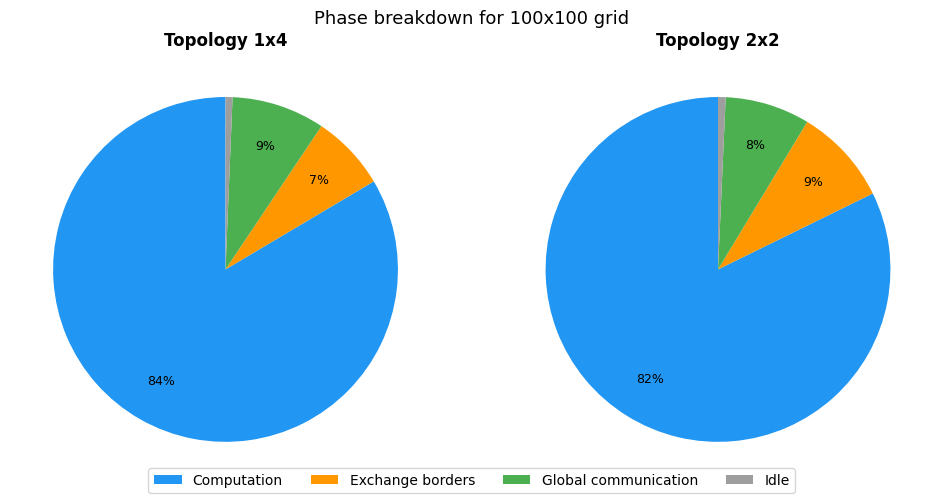

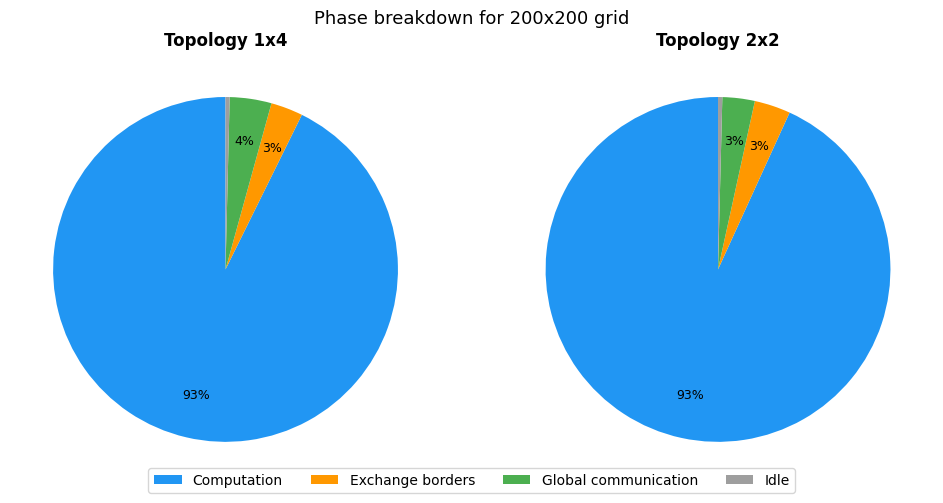

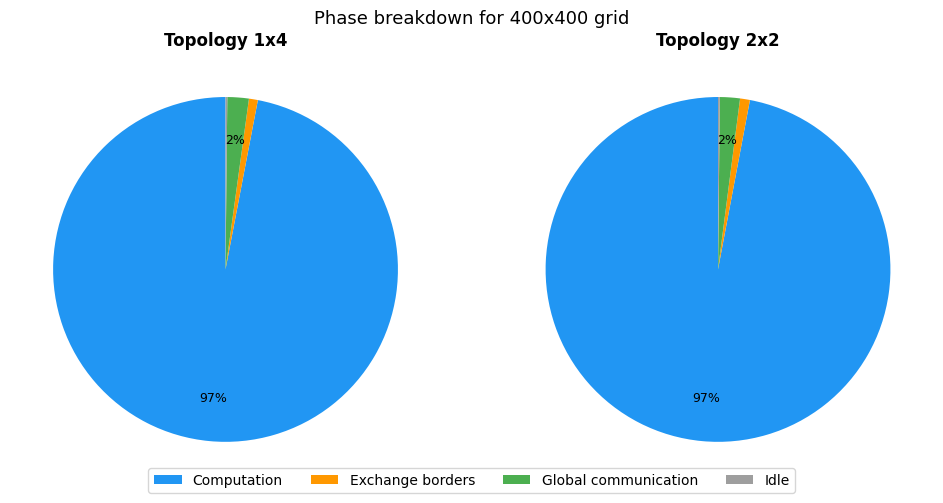

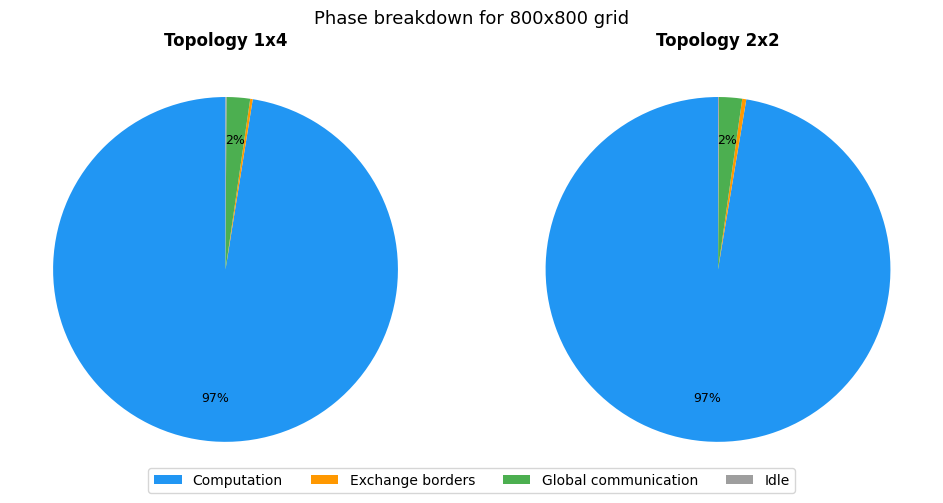

In [13]:
sizes = [100, 200, 400, 800]
topologies = ['1x4', '2x2']
phases = ['Computation', 'Exchange', 'Global comm', 'Idle']
legend_labels = ['Computation', 'Exchange borders', 'Global communication', 'Idle']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9E9E9E']

for s in sizes:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for col, topo in enumerate(topologies):
        ax = axes[col]
        vals = [data[(topo, s)][phase] for phase in phases]

        wedges, texts, autotexts = ax.pie(
            vals, labels=phases, colors=colors, autopct='%1.0f%%',
            pctdistance=0.75, startangle=90,
            textprops={'fontsize': 9})

        for t in texts:
            t.set_text('')

        for autotext, v in zip(autotexts, vals):
            if v / sum(vals) < 0.01:
                autotext.set_text('')

        ax.set_title(f'Topology {topo}', fontweight='bold', fontsize=12)

    fig.legend(wedges, legend_labels, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(f'Phase breakdown for {s}x{s} grid', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'pie_charts_{s}.pdf', bbox_inches='tight')
    plt.show()